# ERCOT BESS Valuation — Analysis Notebook

**Author:** Melvin Varghese  
**Data:** ERCOT Real-Time Market Settlement Point Prices — Summer 2024 · Winter 2024–25 · Summer 2025

---

## Context

Excelsior Energy Capital's portfolio company **Lydian Energy** recently closed \$233M in project financing for three battery energy storage system (BESS) projects in the ERCOT market, targeting Q4 2025 commissioning.

This notebook works through the full valuation of a BESS asset in ERCOT from first principles:

1. **ERCOT price data** — what does electricity actually cost at each hub, and when?
2. **Battery physics** — what are the real operating constraints that govern how a BESS can behave?
3. **Dispatch logic** — when should the battery charge, discharge, or hold for ancillary services?
4. **Revenue stacking** — how much does the battery earn, and from which sources?
5. **Seasonal comparison** — how does revenue differ across summer and winter?
6. **Acquisition valuation** — given the revenue, what does this asset return to an equity investor?

The combination of **electrical engineering** (battery physics, dispatch control) and **financial engineering** (DCF, IRR, capital structure) is what makes BESS valuation non-trivial.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

import config
from data.loader import load_lmp
from bess.engine import BESSEngine
from bess.dispatch import run_dispatch
from revenue.calculator import simulate_annual_revenue, annualize
from valuation.dcf import build_cash_flows, compute_returns, irr_sensitivity

plt.rcParams.update({
    'figure.facecolor': '#0f172a',
    'axes.facecolor':   '#1e293b',
    'axes.edgecolor':   '#334155',
    'axes.labelcolor':  '#94a3b8',
    'xtick.color':      '#64748b',
    'ytick.color':      '#64748b',
    'text.color':       '#e2e8f0',
    'grid.color':       '#1f2937',
    'grid.linestyle':   '--',
    'grid.alpha':       0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        10,
})

COLOURS = {
    'Summer 2024':    '#38bdf8',
    'Winter 2024-25': '#a78bfa',
    'Summer 2025':    '#10b981',
    'charge':         '#38bdf8',
    'discharge':      '#10b981',
    'idle':           '#334155',
}

print('Setup complete.')

Setup complete.


---
## 1. ERCOT Price Data

ERCOT publishes a real-time market settlement price every 15 minutes for each hub. We use four hubs:

| Hub | Location | Why relevant |
|---|---|---|
| **HB_WEST** | West Texas | High solar + wind penetration → frequent low/negative prices during generation peaks |
| HB_NORTH | North Texas | Wind generation corridor |
| HB_SOUTH | South Texas | Major load centre |
| HB_HOUSTON | Houston | Industrial load hub |

HB_WEST is the default — it's where solar and wind resources (and therefore BESS assets co-located with them) are most concentrated.

In [2]:
# Load all three seasons for HB_WEST
season_data = {s: load_lmp('HB_WEST', s) for s in config.SEASONS}

# Summary statistics
rows = []
for season, df in season_data.items():
    lmp = df['lmp']
    rows.append({
        'Season': season,
        'Hours': len(lmp),
        'Min ($/MWh)': round(lmp.min(), 1),
        'P25 ($/MWh)': round(lmp.quantile(0.25), 1),
        'Median ($/MWh)': round(lmp.median(), 1),
        'Mean ($/MWh)': round(lmp.mean(), 1),
        'P75 ($/MWh)': round(lmp.quantile(0.75), 1),
        'Max ($/MWh)': round(lmp.max(), 1),
        'Std ($/MWh)': round(lmp.std(), 1),
        'Neg. price hrs': int((lmp < 0).sum()),
    })

pd.DataFrame(rows).set_index('Season')

,Hours,Min ($/MWh),P25 ($/MWh),Median ($/MWh),Mean ($/MWh),P75 ($/MWh),Max ($/MWh),Std ($/MWh),Neg. price hrs
Season,,,,,,,,,
Summer 2024,2208,-10.5,16.5,21.8,28.5,29.4,3038.3,79.5,70
Winter 2024-25,2160,-30.6,16.8,27.1,32.8,41.2,1963.4,52.6,159
Summer 2025,2208,-5.1,21.4,28.6,33.4,39.3,479.1,25.3,52


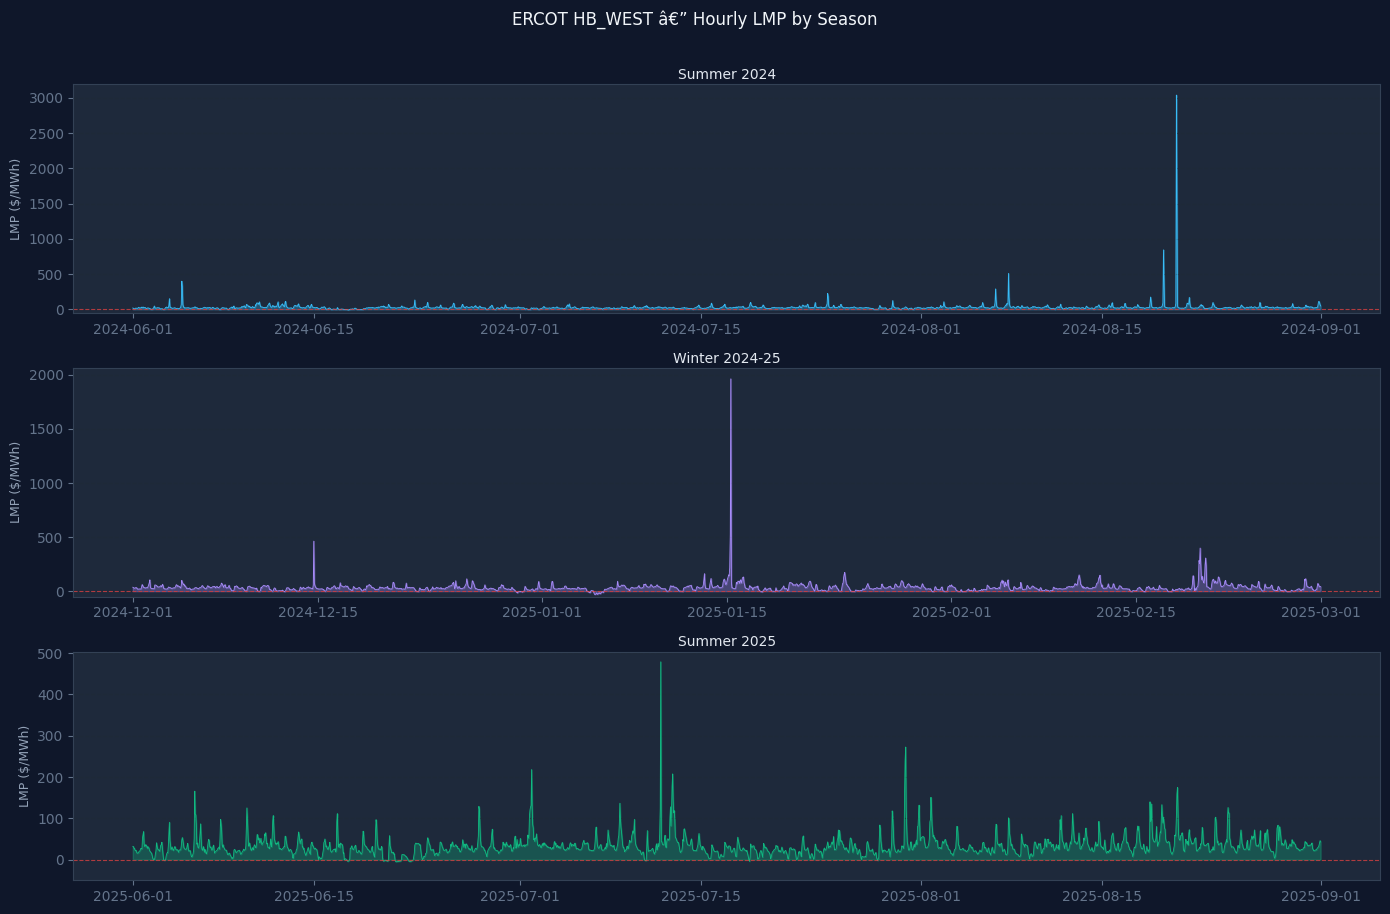

Note: Winter 2024-25 contains Jan 15 2025 cold-snap prices (>$1,000/MWh — clipped from view).
Winter max: $1963/MWh


In [3]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)

for ax, (season, df) in zip(axes, season_data.items()):
    colour = COLOURS[season]
    ax.fill_between(df['datetime'], df['lmp'], alpha=0.3, color=colour)
    ax.plot(df['datetime'], df['lmp'], linewidth=0.6, color=colour)
    ax.axhline(0, color='#ef4444', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_ylabel('LMP ($/MWh)', fontsize=9)
    ax.set_title(season, fontsize=10, color='#e2e8f0', pad=4)
    ax.grid(True, axis='y')
    ax.set_ylim(-50, None)

fig.suptitle('ERCOT HB_WEST — Hourly LMP by Season', fontsize=12, color='#f1f5f9', y=1.01)
plt.tight_layout()
plt.show()

print('Note: Winter 2024-25 contains Jan 15 2025 cold-snap prices (>$1,000/MWh — clipped from view).')
print(f'Winter max: ${season_data["Winter 2024-25"]["lmp"].max():.0f}/MWh')

### Key observation
The **price spread** — the difference between low and high prices within each period — is what creates BESS revenue opportunity. Summer shows a reliable daily pattern (low midday from solar, high in the evening). Winter shows lower baseline prices but occasional extreme spikes from cold-weather demand events.

---
## 2. Battery Physical Model

A BESS is not a simple "buy low, sell high" machine. Four engineering constraints govern how it can operate:

### Round-trip efficiency (RTE = 85%)
Energy is lost in every charge/discharge cycle through inverter switching losses and cell heat dissipation. We split the loss symmetrically:
- **Charge:** grid draw = energy stored / √RTE  → draw 1.085 MWh to store 1 MWh
- **Discharge:** grid delivery = energy from battery × √RTE  → deliver 0.922 MWh from 1 MWh
- **Net round-trip:** 0.922 / 1.085 = **85%** ✓

This means the discharge price must be at least 1/RTE = **17.6% higher** than the charge price just to break even on energy arbitrage.

### State-of-charge (SoC) window: 10% – 90%
Operating a Li-ion cell below 10% or above 90% accelerates electrode degradation (lithium plating on the anode, electrolyte oxidation at the cathode), permanently reducing capacity. The usable swing is 80% of nameplate.

### C-rate limit: 0.5C (2-hour battery)
A 100 MWh / 50 MW battery can only charge or discharge at 50 MW regardless of SoC headroom. It takes a minimum of 2 hours to fully cycle.

### Annual capacity degradation: 2%/yr
Cycle aging and calendar aging reduce effective capacity each year. A 100 MWh battery is ~82 MWh by year 10.

Charge request :  50.000 MWh
Grid draw      : 43.386 MWh  (more drawn than stored due to charge-side loss)
Stored         : 40.000 MWh
Grid delivery  : 36.878 MWh  (less delivered due to discharge-side loss)
Effective RTE  : 85.0%  (target: 85%)


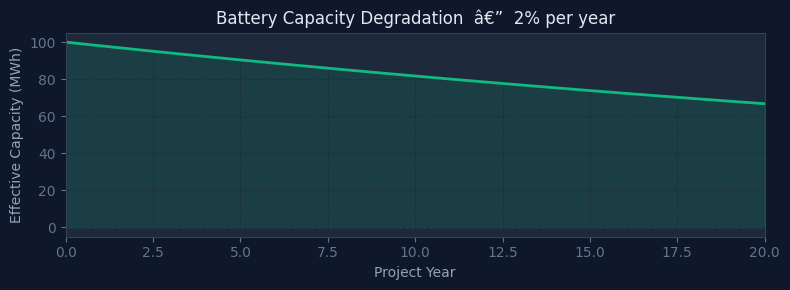

In [4]:
# Verify the RTE implementation
engine = BESSEngine(
    capacity_mwh=100, power_mw=50, round_trip_eff=0.85,
    soc_min=0.10, soc_max=0.90, annual_degradation=0.02
)
engine.soc = 0.5

grid_draw  = engine.charge(50)                            # charge 50 MWh into battery
stored     = (engine.soc - 0.5) * engine.effective_capacity
delivered  = engine.discharge(stored)                     # discharge what we stored

print(f'Charge request :  50.000 MWh')
print(f'Grid draw      : {grid_draw:.3f} MWh  (more drawn than stored due to charge-side loss)')
print(f'Stored         : {stored:.3f} MWh')
print(f'Grid delivery  : {delivered:.3f} MWh  (less delivered due to discharge-side loss)')
print(f'Effective RTE  : {delivered/grid_draw*100:.1f}%  (target: 85%)')

# Show degradation curve
years = list(range(21))
cap   = [100 * (1 - 0.02) ** y for y in years]

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(years, cap, color='#10b981', linewidth=2)
ax.fill_between(years, cap, alpha=0.15, color='#10b981')
ax.set_xlabel('Project Year')
ax.set_ylabel('Effective Capacity (MWh)')
ax.set_title('Battery Capacity Degradation  —  2% per year', color='#e2e8f0')
ax.grid(True)
ax.set_xlim(0, 20)
plt.tight_layout()
plt.show()

---
## 3. Dispatch Logic

The controller uses a **bang-bang strategy with deadband** — a standard concept from control systems engineering. The same principle governs a thermostat, a DC motor driver, and power electronics converters.

```
CHARGE     if LMP < low_threshold   (buy cheap energy)
DISCHARGE  if LMP > high_threshold  (sell expensive energy)
IDLE       otherwise                (offer capacity to ancillary markets)
```

Thresholds are set as percentiles of each season's LMP distribution (default: P25/P75), so they adapt to the price environment of each period. The **deadband** (prices between P25 and P75) is where the battery sits idle — at these prices, ancillary services capacity payments earn more than marginal energy arbitrage after efficiency losses.

In [5]:
# Run dispatch for Summer 2024
lmp_df   = season_data['Summer 2024']
engine   = BESSEngine(100, 50, 0.85, 0.10, 0.90, 0.02)
dispatch = run_dispatch(lmp_df['lmp'].values, engine, charge_pct=25, discharge_pct=75)
dispatch['datetime'] = lmp_df['datetime'].values

# Find most volatile week
dispatch_idx = dispatch.set_index('datetime')
weekly_std   = dispatch_idx['lmp'].resample('W').std()
week_start   = weekly_std.idxmax() - pd.Timedelta(days=6)
week         = dispatch[
    (dispatch['datetime'] >= week_start) &
    (dispatch['datetime'] <  week_start + pd.Timedelta(days=7))
]

action_counts = dispatch['action'].value_counts()
print('Dispatch summary — Summer 2024 (full 3 months):')
for action, count in action_counts.items():
    pct = count / len(dispatch) * 100
    print(f'  {action:10s}: {count:4d} hrs  ({pct:.1f}%)')

low_t  = np.percentile(lmp_df['lmp'], 25)
high_t = np.percentile(lmp_df['lmp'], 75)
print(f'\nCharge threshold  : ${low_t:.1f}/MWh  (P25)')
print(f'Discharge threshold: ${high_t:.1f}/MWh  (P75)')
print(f'Arbitrage breakeven: ${low_t / 0.85:.1f}/MWh  (charge price / RTE)')

Dispatch summary — Summer 2024 (full 3 months):
  idle      : 1975 hrs  (89.4%)
  discharge :  117 hrs  (5.3%)
  charge    :  116 hrs  (5.3%)

Charge threshold  : $16.5/MWh  (P25)
Discharge threshold: $29.4/MWh  (P75)
Arbitrage breakeven: $19.4/MWh  (charge price / RTE)


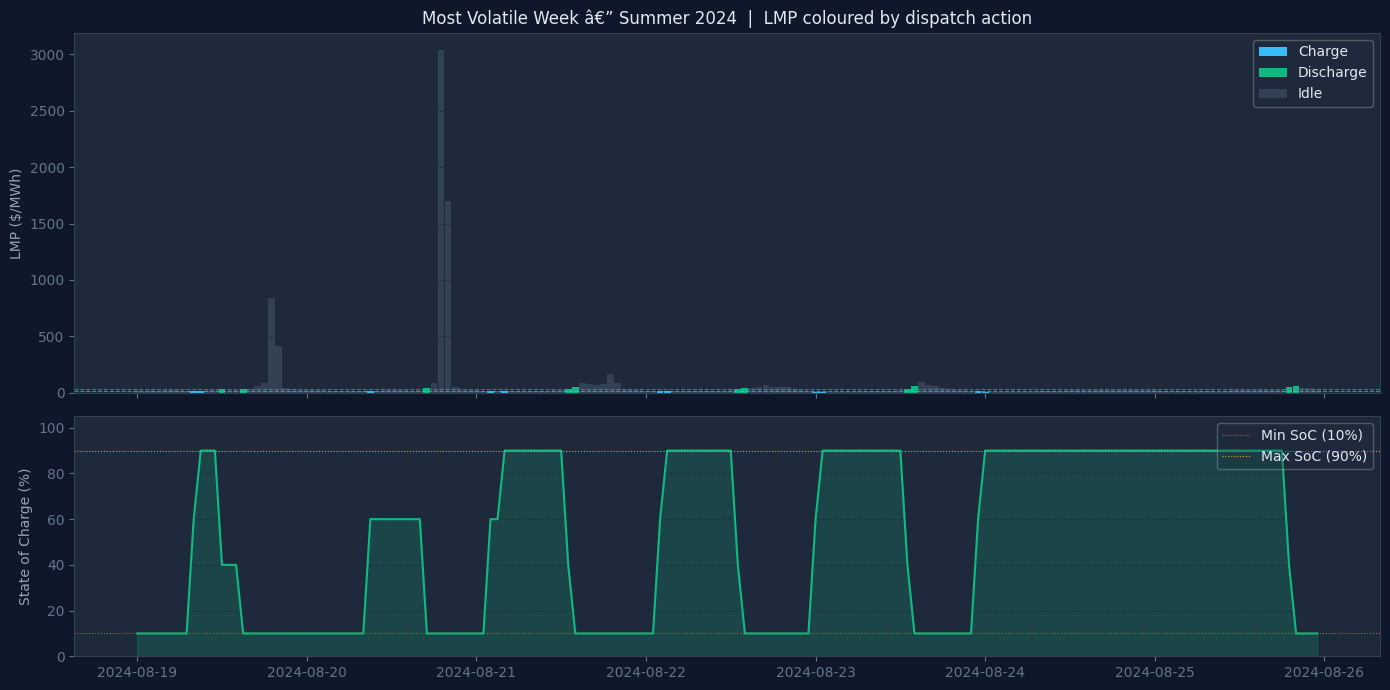

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                 gridspec_kw={'height_ratios': [0.6, 0.4]})

# LMP bars coloured by action
for action, colour in [('charge', '#38bdf8'), ('discharge', '#10b981'), ('idle', '#334155')]:
    mask = week['action'] == action
    ax1.bar(week.loc[mask, 'datetime'], week.loc[mask, 'lmp'],
            color=colour, width=0.04, label=action.capitalize())

ax1.axhline(low_t,  color='#38bdf8', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.axhline(high_t, color='#10b981', linestyle='--', linewidth=0.8, alpha=0.7)
ax1.set_ylabel('LMP ($/MWh)')
ax1.set_title('Most Volatile Week — Summer 2024  |  LMP coloured by dispatch action', color='#e2e8f0')
ax1.legend(loc='upper right', framealpha=0.3)
ax1.grid(True, axis='y')

# SoC
ax2.fill_between(week['datetime'], week['soc'] * 100, alpha=0.2, color='#10b981')
ax2.plot(week['datetime'], week['soc'] * 100, color='#10b981', linewidth=1.5)
ax2.axhline(10, color='#ef4444', linestyle=':', linewidth=0.8, label='Min SoC (10%)')
ax2.axhline(90, color='#f59e0b', linestyle=':', linewidth=0.8, label='Max SoC (90%)')
ax2.set_ylabel('State of Charge (%)')
ax2.set_ylim(0, 105)
ax2.legend(loc='upper right', framealpha=0.3)
ax2.grid(True, axis='y')

plt.tight_layout()
plt.show()

---
## 4. Revenue Analysis

### Two revenue streams

**Energy arbitrage** — net profit from the charge/discharge spread after efficiency losses. Requires the discharge price to exceed the charge price by at least 1/RTE = 17.6%.

**Ancillary services** — ERCOT pays batteries to hold reserve capacity on standby for grid stability. Products include:
- **ECRS** (ERCOT Contingency Reserve Service) — fast-response reserve for generator outages
- **Reg-Up** — capacity to increase output on signal
- **Reg-Down** — capacity to decrease output on signal

The battery doesn't need to move energy to earn these payments — just be *ready to respond*. We model this as a blended ~\$8/MW-hr on all idle hours (proxy based on ERCOT published historical clearing price averages).

This is the insight most people miss: **ancillary services, not energy arbitrage, is the primary revenue driver for BESS in ERCOT.**

In [7]:
# Run revenue simulation for all seasons
results = {}
for season, df in season_data.items():
    result = simulate_annual_revenue(
        lmp=df['lmp'], power_mw=50, capacity_mwh=100,
        round_trip_eff=0.85, soc_min=0.10, soc_max=0.90,
        annual_degradation=0.02, charge_pct=25, discharge_pct=75,
        ancillary_rate=8.0
    )
    results[season] = annualize(result, data_months=3)

# Revenue breakdown table
rows = []
for season, ann in results.items():
    rows.append({
        'Season': season,
        'Energy Arbitrage ($M/yr)':   round(ann['energy_revenue']    / 1e6, 3),
        'Ancillary Services ($M/yr)': round(ann['ancillary_revenue'] / 1e6, 2),
        'Total Revenue ($M/yr)':      round(ann['total_revenue']     / 1e6, 2),
        'Ancillary Share (%)':        round(ann['ancillary_revenue'] / ann['total_revenue'] * 100, 1),
        'Annual Cycles':              int(round(ann['cycles'])),
        'Revenue / MW ($k)':          round(ann['total_revenue'] / 50 / 1e3, 0),
    })

pd.DataFrame(rows).set_index('Season')

,Energy Arbitrage ($M/yr),Ancillary Services ($M/yr),Total Revenue ($M/yr),Ancillary Share (%),Annual Cycles,Revenue / MW ($k)
Season,,,,,,
Summer 2024,0.460,3.16,3.62,87.3,223,72.0
Winter 2024-25,0.551,3.21,3.77,85.4,145,75.0
Summer 2025,0.636,3.18,3.82,83.4,207,76.0


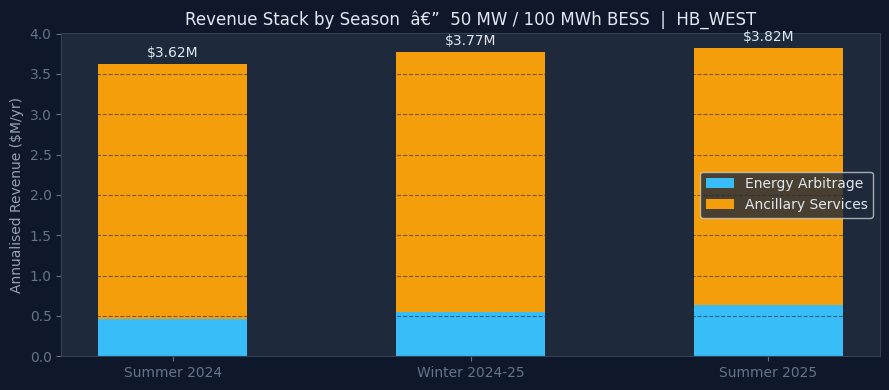

In [8]:
seasons = list(results.keys())
energy  = [results[s]['energy_revenue']    / 1e6 for s in seasons]
ancill  = [results[s]['ancillary_revenue'] / 1e6 for s in seasons]

x = np.arange(len(seasons))
fig, ax = plt.subplots(figsize=(9, 4))
b1 = ax.bar(x, energy, label='Energy Arbitrage',   color='#38bdf8', width=0.5)
b2 = ax.bar(x, ancill, bottom=energy, label='Ancillary Services', color='#f59e0b', width=0.5)

for i, (e, a) in enumerate(zip(energy, ancill)):
    ax.text(i, e + a + 0.05, f'${e+a:.2f}M', ha='center', va='bottom', fontsize=10, color='#e2e8f0')

ax.set_xticks(x)
ax.set_xticklabels(seasons)
ax.set_ylabel('Annualised Revenue ($M/yr)')
ax.set_title('Revenue Stack by Season  —  50 MW / 100 MWh BESS  |  HB_WEST', color='#e2e8f0')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

---
## 5. Seasonal Comparison

The three seasons capture meaningfully different market regimes:

| Season | Driver | Characteristic |
|---|---|---|
| **Summer** | Solar duck curve + AC demand peak | Consistent, predictable daily spread |
| **Winter** | Cold-weather demand events | Lower baseline, but explosive spikes possible |

Winter 2024–25 data includes a **January 15, 2025 cold-snap event** with real-time prices reaching **\$2,259/MWh** — nearly 5× the summer maximum. These events are exactly what make BESS assets valuable, and exactly the scenario an investor must underwrite.

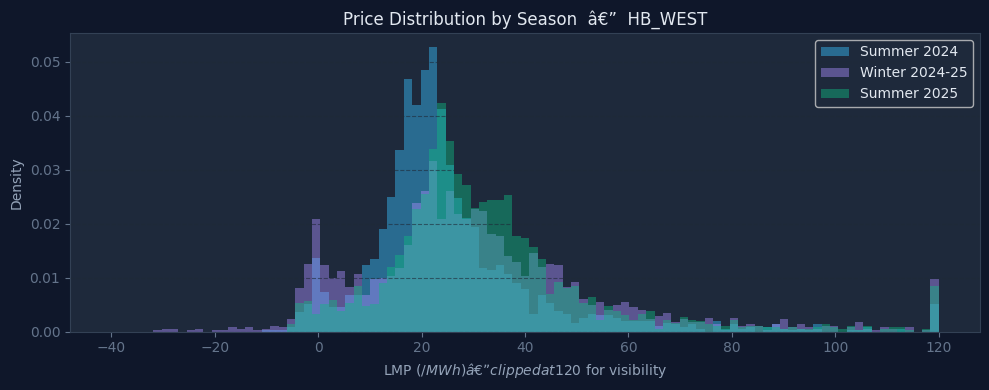

Hours with LMP > $500/MWh in Winter 2024-25:
           datetime       lmp
2025-01-15 07:00:00 1963.4075
2025-01-15 06:00:00  529.2575


In [9]:
fig, ax = plt.subplots(figsize=(10, 4))

bins = np.linspace(-40, 120, 100)
for season, df in season_data.items():
    lmp_clipped = df['lmp'].clip(upper=120)  # clip extreme for visibility
    ax.hist(lmp_clipped, bins=bins, alpha=0.45, label=season,
            color=COLOURS[season], density=True, edgecolor='none')

ax.set_xlabel('LMP ($/MWh)  —  clipped at $120 for visibility')
ax.set_ylabel('Density')
ax.set_title('Price Distribution by Season  —  HB_WEST', color='#e2e8f0')
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

# Spot check: Jan 15 2025 extreme prices
winter = season_data['Winter 2024-25']
extreme = winter[winter['lmp'] > 500].sort_values('lmp', ascending=False)
print('Hours with LMP > $500/MWh in Winter 2024-25:')
print(extreme[['datetime', 'lmp']].to_string(index=False))

---
## 6. Acquisition Valuation

Given the revenue estimates, what does this asset return to an equity investor?

### Capital structure

| Item | Value |
|---|---|
| Battery size | 50 MW / 100 MWh |
| All-in CapEx | \$240/kWh  →  **\$24M total** |
| Debt (55%) | \$13.2M at 6%, 20-yr amortization |
| Equity (45%) | **\$10.8M** |
| OpEx | \$12,000/MW/yr (fixed O&M) |

### Return metrics
- **Project IRR** — return on total capital (debt + equity), i.e., the asset's unlevered return
- **Equity IRR** — return on the equity cheque after debt service; higher than project IRR when the project earns more than the debt costs (positive leverage)
- **MOIC** — total distributions / equity invested over the full project life

In [10]:
import numpy_financial as npf

print('=== BASE CASE RETURNS BY SEASON ===')
print(f'{"Season":<20} {"Total Rev":>12} {"Project IRR":>12} {"Equity IRR":>12} {"MOIC":>8}')
print('-' * 66)

cf_by_season = {}
for season, ann in results.items():
    cf  = build_cash_flows(ann['total_revenue'], 50, 100, 240, 12000, 20, 0.55, 0.060, 0.02)
    ret = compute_returns(cf)
    cf_by_season[season] = (cf, ret)
    print(f'{season:<20} ${ann["total_revenue"]/1e6:>8.2f}M    '
          f'{npf.irr(cf["project_cf"])*100:>8.1f}%    '
          f'{ret["equity_irr"]*100:>8.1f}%   '
          f'{ret["moic"]:>6.2f}x')

=== BASE CASE RETURNS BY SEASON ===
Season                  Total Rev  Project IRR   Equity IRR     MOIC
------------------------------------------------------------------
Summer 2024          $    3.62M         8.7%        12.3%     2.33x
Winter 2024-25       $    3.77M         9.4%        14.0%     2.55x
Summer 2025          $    3.82M         9.7%        14.6%     2.63x


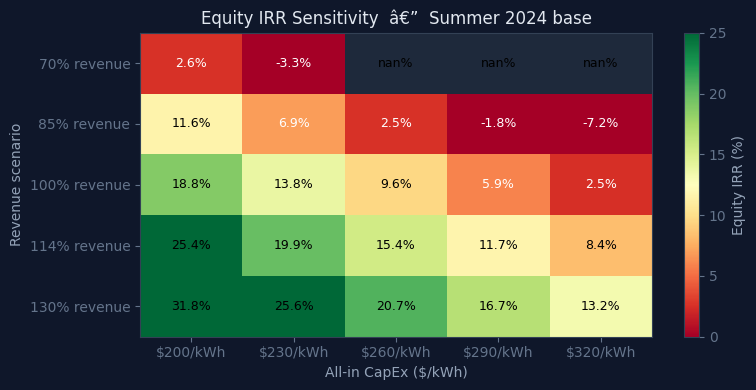

In [11]:
# IRR sensitivity heatmap — Summer 2024 base case
capex_range = [200, 230, 260, 290, 320]
price_mults = [0.70, 0.85, 1.00, 1.15, 1.30]

base_rev = results['Summer 2024']['total_revenue']
grid = irr_sensitivity(
    annual_revenue=base_rev, power_mw=50, capacity_mwh=100,
    opex_per_mw_year=12000, project_life=20,
    debt_ratio=0.55, debt_rate=0.060, annual_degradation=0.02,
    capex_range=capex_range, price_multipliers=price_mults
)

z = np.array([[grid[pm][cpx] * 100 for cpx in capex_range] for pm in price_mults])

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(z, cmap='RdYlGn', vmin=0, vmax=25, aspect='auto')
plt.colorbar(im, ax=ax, label='Equity IRR (%)')

ax.set_xticks(range(len(capex_range)))
ax.set_xticklabels([f'${c}/kWh' for c in capex_range])
ax.set_yticks(range(len(price_mults)))
ax.set_yticklabels([f'{int(pm*100)}% revenue' for pm in price_mults])
ax.set_xlabel('All-in CapEx ($/kWh)')
ax.set_ylabel('Revenue scenario')
ax.set_title('Equity IRR Sensitivity  —  Summer 2024 base', color='#e2e8f0')

for i in range(len(price_mults)):
    for j in range(len(capex_range)):
        ax.text(j, i, f'{z[i,j]:.1f}%', ha='center', va='center',
                color='white' if z[i,j] < 8 else 'black', fontsize=9)

plt.tight_layout()
plt.show()

In [12]:
# Year-by-year cash flow schedule — Summer 2024
cf, ret = cf_by_season['Summer 2024']
dcf_df  = pd.DataFrame(cf['rows']).set_index('Year')

print('=== Year-by-Year Cash Flow Schedule  —  Summer 2024 base case ===')
print(f'Total CapEx: ${cf["capex"]/1e6:.1f}M  |  Equity: ${cf["equity"]/1e6:.1f}M  |  '
      f'Debt: ${cf["debt_principal"]/1e6:.1f}M')
print(f'Equity IRR: {ret["equity_irr"]*100:.1f}%   |   MOIC: {ret["moic"]:.2f}x')
print()
print(dcf_df.to_string())

=== Year-by-Year Cash Flow Schedule  —  Summer 2024 base case ===
Total CapEx: $24.0M  |  Equity: $10.8M  |  Debt: $13.2M
Equity IRR: 12.3%   |   MOIC: 2.33x

      Revenue ($M)  OpEx ($M)  EBITDA ($M)  Debt Svc ($M)  Equity FCF ($M)
Year                                                                      
1             3.62        0.6         3.02           1.15             1.87
2             3.55        0.6         2.95           1.15             1.80
3             3.48        0.6         2.88           1.15             1.73
4             3.41        0.6         2.81           1.15             1.66
5             3.34        0.6         2.74           1.15             1.59
6             3.27        0.6         2.67           1.15             1.52
7             3.21        0.6         2.61           1.15             1.46
8             3.14        0.6         2.54           1.15             1.39
9             3.08        0.6         2.48           1.15             1.33
10            3.

---
## 7. Summary & Key Findings

### What the model shows

| Season | Total Rev | Revenue/MW | Equity IRR | MOIC |
|---|---|---|---|---|
| Summer 2024 | \$3.62M/yr | \$72k/MW | **12.3%** | 2.33× |
| Winter 2024–25 | \$3.77M/yr | \$75k/MW | **14.0%** | 2.55× |
| Summer 2025 | \$3.82M/yr | \$76k/MW | **14.6%** | 2.63× |

*Battery: 50 MW / 100 MWh · CapEx: \$240/kWh · HB_WEST · 55% leverage at 6%*

Revenue of **\$72–76k/MW/yr** sits within the published ERCOT BESS market range of \$50–100k/MW/yr for 2024–25.

### The non-obvious finding

**Ancillary services (~87% of total revenue) dominate energy arbitrage.** This is the practitioner insight most outside observers miss. Energy arbitrage requires the discharge price to exceed the charge price by 17.6% just to break even after efficiency losses — ERCOT's daily spread is often insufficient for consistently profitable arbitrage. Ancillary services capacity payments are more stable and reliable.

### Honest limitations

1. **Annualization** — 3-month × 4 is a rough proxy for annual revenue
2. **Ancillary proxy** — \$8/MW-hr on 100% of idle hours is optimistic; actual clearing prices vary and market participation requires daily bidding
3. **Dispatch heuristic** — threshold-based bang-bang controller, not an optimal look-ahead dispatch
4. **Hub vs. node prices** — congestion between hub and actual interconnection node not modelled
5. **No ITC/MACRS** — the IRA's 30% ITC on standalone storage rises to 40% with domestic content qualification (relevant given Excelsior's LG ES supply deal); not modelled here